# Lesson 04 — Building makemore Part 3: Activations & Gradients, BatchNorm

- **GitHub issue:** [#4](https://github.com/majorgilles/karpathy_ml_course/issues/4)
- **Video:** https://youtu.be/P6sfmUTpUmc
- **Lesson guide:** [../README.md](../README.md)
- **Transcript:** [../transcript.md](../transcript.md)

Use this notebook for exploratory follow-along work. Move reusable code to `../src/`, lightweight checks to `../tests/`, and representative outputs to `../artifacts/`.

## 1. Load names and prepare the diagnostic workspace

This lesson starts from the same character-level name data as the previous MLP lesson so that later activation and gradient observations can be compared on the same prediction problem. `torch` supplies tensor operations, `torch.nn.functional` supplies neural-network helpers, and `matplotlib` is prepared for later plots. `%matplotlib inline` keeps those plots inside the notebook; the imported `float32` symbol is not used by the current cells.

The input is `data/raw/names.txt`, with a fallback path for running the kernel from this notebook's folder. `splitlines()` produces `words`, a Python list containing one complete name per element. The current output confirms the first eight names and a total of 32,033 names. Next, each character needs a stable numeric ID before it can appear in a model input.

In [1]:
import torch  # Tensor operations and model parameters.
import torch.nn.functional as F  # One-hot encoding and other neural-network helpers.
import matplotlib.pyplot as plt  # Visualizations used later in the lesson.
from sympy.codegen.ast import float32  # Current exploration import; not used by these cells yet.
%matplotlib inline

In [2]:
# Load every name; each line in names.txt becomes one training sequence.
from pathlib import Path

candidate_paths = [
    Path("data/raw/names.txt"),  # Kernel launched from the repository root.
    Path("../../../data/raw/names.txt"),  # Kernel launched from this notebook folder.
]
names_path = next(path for path in candidate_paths if path.exists())
words = names_path.read_text(encoding="utf-8").splitlines()

words[:8]  # Inspect a small sample before building numeric examples.

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# Confirm how many complete name sequences are available.
len(words)

32033

## 2. Map characters to model-friendly IDs

The model consumes integer token IDs rather than Python characters. The input is the complete `words` list: `''.join(words)` combines its text, `set(...)` keeps each character once, and `sorted(...)` gives the discovered letters a stable alphabetical order. Discovering the vocabulary from the data also avoids assuming in advance that every dataset contains exactly `a` through `z`.

`stoi` means string-to-index and maps each letter to IDs `1` through `26`; `itos` reverses that mapping for readable output. The boundary token `.` receives ID `0` and will represent both padding before a name and the end after its final letter. The output is therefore a 27-token vocabulary. Next, `BLOCK_SIZE` determines how many preceding token IDs form one input context.

In [4]:
# Collect the 26 lowercase letters once and sort them for reproducible IDs.
chars = sorted(list(set(''.join(words))))
# Reserve 0 for the boundary token, so letters begin at index 1.
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
# Invert the mapping: model indices back to printable characters.
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## 3. Set the model and optimization hyperparameters

A **hyperparameter** is a setting chosen outside gradient-based training. `BLOCK_SIZE = 3` gives every example three preceding token IDs; `EMBEDDING_SIZE = 10` gives each token a 10-feature vector; and `HIDDEN_SIZE = 200` sets the width of the MLP's hidden layer. `VOCAB_SIZE` is derived from `stoi`, so the current model scores all 27 vocabulary candidates.

Training uses mini-batches of 32 examples for 200,000 parameter-update **steps**. A step processes one randomly sampled mini-batch. It is not an epoch, because an epoch would mean processing every training example once; replacement sampling can repeat some rows and omit others. These values determine the dataset width, parameter shapes, and loop bounds in the next cells.

In [5]:
BLOCK_SIZE = 3  # Number of preceding character IDs in each model input.
EMBEDDING_SIZE = 10  # Learnable features used to represent each token.
HIDDEN_SIZE = 200  # Number of neurons in the MLP hidden layer.
VOCAB_SIZE = len(stoi)  # Twenty-six letters plus the boundary token.
NUMBER_STEPS = 200_000  # Random mini-batch updates, not full-dataset epochs.
MINIBATCH_SIZE = 32  # Training examples contributing to one update.

## 4. Build context-target rows and split complete names

`build_dataset` receives a list of complete names and uses `stoi` plus `BLOCK_SIZE` to produce aligned tensors. For each name, `context` starts as `[0, 0, 0]`. Every loop iteration appends that three-ID context to `X`, appends the one observed next-character ID to `Y`, and then slides the window forward. Iterating over `w + '.'` also creates the final example whose expected target is the end-of-name token.

Each row `X[i]` is one training example's input, while `Y[i]` is its single expected target. The vocabulary contains 27 possible next-token candidates, but this cell does not calculate their probabilities or a loss yet; a later forward pass will assign 27 scores and the probability indexed by `Y[i]` will contribute directly to that example's loss.

On a clean top-to-bottom run, `random.seed(42)` makes the name-level shuffle reproducible. The first 80% of complete names create `Xtr` and `Ytr`, the next 10% create `Xdev` and `Ydev`, and the final 10% create `Xte` and `Yte`. Splitting names before generating rows prevents transitions from one name leaking across splits. The current outputs are `182,625` training rows, `22,655` development rows, and `22,866` test rows, all with three context IDs and one target ID per row. Row percentages differ slightly from 80/10/10 because names have different lengths.

Only `Xtr` and `Ytr` should supply parameter updates. Development data is for comparing choices, and test data stays untouched until final evaluation. The next cells initialize the same baseline MLP as Lesson 03 and preserve its intermediate tensors for activation and gradient inspection.

In [6]:
# Turn one supplied name split into aligned context rows X and next-character targets Y.
def build_dataset(words: list) -> tuple[torch.Tensor, torch.Tensor]:
    X, Y = [], []
    for w in words:  # Keep every transition from this split together.
        context = [0] * BLOCK_SIZE  # Start with three boundary-token IDs: "...".

        for ch in w + ".":  # Include the final boundary token as a target.
            ix = stoi[ch]  # Integer ID of the character this context should predict.
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # Drop the oldest ID and append this target ID.

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, X.dtype, Y.shape, Y.dtype)  # Inspect this split's context and target tensors.
    return X, Y

import random
random.seed(42)  # Reproduce the same name-level split on each rerun.
random.shuffle(words)  # Shuffle complete names before slicing; do not split individual transitions.
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# Build training, development, and test tensors from disjoint name groups.
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.int64 torch.Size([182625]) torch.int64
torch.Size([22655, 3]) torch.int64 torch.Size([22655]) torch.int64
torch.Size([22866, 3]) torch.int64 torch.Size([22866]) torch.int64


## 5. Recreate the baseline MLP parameters

The fixed generator seed makes a fresh top-to-bottom run reproduce the same initial parameters. `C` is the `(27, 10)` embedding table. Flattening three embeddings gives 30 inputs to `W1`, so `W1` has shape `(30, 200)` and `b1` has one bias for each of the 200 hidden neurons. `W2` then maps those hidden activations to 27 output logits, with `b2` supplying one output bias per vocabulary candidate.

The five tensors contain 11,897 trainable scalar parameters in total:

$$
27 \times 10 + 30 \times 200 + 200 + 200 \times 27 + 27 = 11{,}897
$$

`requires_grad=True` asks PyTorch to retain the computation needed for backpropagation. The unscaled random-normal initialization intentionally recreates the baseline that this lesson will diagnose; improved initialization has not been applied yet. Next, the training loop exposes values before and after `tanh` instead of hiding them inside one expression.

In [7]:
# Use a local fixed seed so this baseline parameter initialization is reproducible.
g = torch.Generator().manual_seed(2147483647)
# Keep each intermediate shape explicit for later activation and gradient diagnostics.
C = torch.randn(VOCAB_SIZE, EMBEDDING_SIZE, generator=g)  # (27, 10)
W1 = torch.randn((BLOCK_SIZE * EMBEDDING_SIZE, HIDDEN_SIZE), generator=g)  # (30, 200)
b1 = torch.randn(HIDDEN_SIZE, generator=g)  # (200,)
W2 = torch.randn((HIDDEN_SIZE, VOCAB_SIZE), generator=g)  * 0.01 # (200, 27)
b2 = torch.randn(VOCAB_SIZE, generator=g) * 0  # (27,)
# Keep the five trainable tensors together for gradient clearing and updates.
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [8]:
# Count every trainable scalar across the embedding, hidden, and output parameters.
sum(p.nelement() for p in parameters)

11897

## 6. Train while keeping diagnostic tensors visible

This loop performs the same MLP computation as Lesson 03, but it names more intermediate results. `Xb` and `Yb` preserve one sampled mini-batch of paired contexts and targets. `embcat` is the flattened `(B, 30)` MLP input, `hpreact` is the `(B, 200)` linear result before `tanh`, and `h` is the `(B, 200)` activation after `tanh`. Keeping `hpreact` and `h` separate makes their distributions available for the diagnostics introduced later in this lesson.

For each of the `B = 32` training examples, `logits` contains 27 candidate scores and `Yb[i]` identifies the one expected target. Cross-entropy converts those scores internally to probabilities and averages the negative log-probability assigned to the expected targets:

$$
\mathcal{L}_{\mathrm{batch}} = -\frac{1}{B} \sum_{i=1}^{B} \log p_{i, Y_{b,i}}
$$

Here, `B` is the number of sampled training examples, `i` identifies one example, `p` is its 27-candidate probability distribution, and `Yb[i]` is its expected target ID. Only `p[i, Yb[i]]` contributes directly to example `i`'s NLL.

The loop runs 200,000 replacement-sampled update steps: learning rate `0.1` for the first half and `0.01` for the second half. `lossi` records the base-10 logarithm of each sampled mini-batch's average NLL; it is neither a full-training-set loss nor a development loss, and no smoothing is applied here. Rerunning only this loop continues training the existing parameters, so rerun the parameter-initialization cell first when you want a fresh experiment. The next concept is to inspect `hpreact`, `h`, and parameter gradients for unhealthy scale or saturation.

In [9]:
# Rerun parameter initialization immediately before this cell for a fresh experiment.
# These are the complete training tensors; only sampled Xb/Yb rows enter each update.
print(Xtr.shape)
print(Ytr.shape)

lossi = []  # Base-10 log of the average NLL from each sampled mini-batch.
for step in range(NUMBER_STEPS):
    # Sample B = 32 training-row IDs uniformly with replacement.
    ix = torch.randint(0, Xtr.shape[0], (MINIBATCH_SIZE,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # Paired batch shapes: (B, 3) contexts and (B,) targets.

    # Forward pass: preserve intermediate tensors for later activation diagnostics.
    emb = C[Xb]  # (B, 3, 10): one embedding vector per context token.
    embcat = emb.view(-1, EMBEDDING_SIZE * BLOCK_SIZE)  # (B, 30): one row per context.
    hpreact = embcat @ W1 + b1  # (B, 200): hidden values before tanh.
    h = torch.tanh(hpreact)  # (B, 200): bounded hidden activations after tanh.
    logits = h @ W2 + b2  # (B, 27): one raw score per vocabulary candidate.
    loss = F.cross_entropy(logits, Yb)  # Average NLL for this batch's B expected targets.

    # Backward pass: clear earlier gradients, then differentiate this mini-batch loss.
    for p in parameters:
        p.grad = None
    loss.backward()

    # Use lr = 0.1 for the first 100,000 steps, then decay to 0.01.
    lr = 0.1 if step < NUMBER_STEPS // 2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad  # Instructional direct parameter update.

    # Print occasional unsmoothed mini-batch NLL and retain every log10 loss value.
    if step % 10_000 == 0:
        print(f"{step:7d}/{NUMBER_STEPS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

torch.Size([182625, 3])
torch.Size([182625])
      0/ 200000: 3.3221
  10000/ 200000: 2.1900
  20000/ 200000: 2.4196
  30000/ 200000: 2.6067
  40000/ 200000: 2.0601
  50000/ 200000: 2.4988
  60000/ 200000: 2.3902
  70000/ 200000: 2.1344
  80000/ 200000: 2.3369
  90000/ 200000: 2.1299
 100000/ 200000: 1.8329
 110000/ 200000: 2.2053
 120000/ 200000: 1.8540
 130000/ 200000: 2.4566
 140000/ 200000: 2.1879
 150000/ 200000: 2.1118
 160000/ 200000: 1.8956
 170000/ 200000: 1.8644
 180000/ 200000: 2.0326
 190000/ 200000: 1.8417


## 7. Plot the unsmoothed mini-batch training history

`lossi` contains one value for every parameter-update step: the base-10 logarithm of that step's average 32-example training NLL. Plotting it against list position therefore uses update step on the horizontal axis and `log10` mini-batch loss on the vertical axis. Lower values mean lower loss, while the visible noise comes from evaluating a different replacement-sampled mini-batch at each step.

This plot uses all 200,000 recorded values without averaging or smoothing. It is useful for seeing the large initial loss and the overall downward trend, but it is not a full-training-set or development-loss curve. The next cell performs those full-split evaluations.

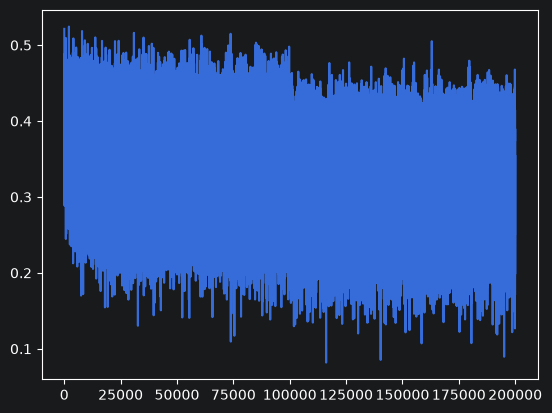

In [10]:
plt.plot(lossi)

## 8. Compare full training and development loss without updating parameters

`split_loss` receives a split name and selects its complete context tensor `x` and expected-target tensor `y`. Unlike the training loop, it performs no mini-batch sampling, `backward()` call, or parameter update. The `@torch.no_grad()` decorator disables gradient bookkeeping because evaluation only needs the forward values and average NLL.

For a split with `N` examples, the forward shape path is `(N, 3)` token IDs → `(N, 3, 10)` embeddings → `(N, 30)` flattened inputs → `(N, 200)` hidden pre-activations and activations → `(N, 27)` candidate logits. Cross-entropy selects the candidate indexed by each expected target `y[i]` and averages NLL over all `N` examples.

The current full-split results are training loss `2.1238` and validation loss `2.1623`, a small gap of about `0.0385`. The dictionary supports the test split, but this cell deliberately evaluates only `train` and `val`; keep `test` untouched until model choices are final. Next, sampling uses the trained candidate probabilities to generate new names rather than score known targets.

In [11]:
@torch.no_grad()  # Evaluation needs forward values but no gradient graph.
def split_loss(split: str) -> None:
    # Select every aligned context-target pair from the requested split.
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]

    emb = C[x]  # (N, 3, 10): embeddings for every context in this split.
    embcat = emb.view(emb.shape[0], -1)  # (N, 30): flatten each context.
    hpreact = embcat @ W1 + b1  # (N, 200): hidden values before tanh.
    h = torch.tanh(hpreact)  # (N, 200): hidden activations after tanh.
    logits = h @ W2 + b2  # (N, 27): candidate scores for every example.
    loss = F.cross_entropy(logits, y)  # Average NLL over the complete split.
    print(split, loss.item())

split_loss("train")
split_loss("val")  # Validation and development refer to the same held-out split here.

train 2.069589138031006
val 2.1310746669769287


## 9. Generate names one character at a time

Generation starts with one batch-of-one context containing three boundary-token IDs. The same trained forward pass produces `(1, 27)` logits, and row-wise softmax converts them into probabilities over all 27 next-token candidates. `torch.multinomial` samples one candidate instead of always choosing the largest probability, so repeated generations can differ while the fixed generator seed keeps this saved run reproducible.

After sampling token ID `ix`, the code removes the oldest context ID, appends `ix`, and records it in `out`. That sampled output therefore becomes part of the next input. Generation ends when the model samples boundary-token ID `0`, and `itos` decodes every recorded ID—including the final `.`—into the printed name. There are no expected targets or loss during generation, and gradient tracking is unnecessary.

The current loop requests 20 names and follows the course's open-ended stopping rule: each name continues until `.` is sampled.

In [12]:
# Use a separate fixed generator so this sequence of sampled names is reproducible.
sample_generator = torch.Generator().manual_seed(2147483647 + 10)

with torch.no_grad():  # Sampling needs probabilities but no gradients or parameter updates.
    for _ in range(20):
        out = []  # Token IDs sampled for this one generated name.
        context = [0] * BLOCK_SIZE  # Batch-of-one context starts as boundary padding: `...`.

        while True:
            # Run the same forward pass for one current context.
            context_tensor = torch.tensor([context], dtype=torch.long)  # (1, 3)
            emb = C[context_tensor]  # (1, 3, 10)
            embcat = emb.view(1, -1)  # (1, 30)
            hpreact = embcat @ W1 + b1  # (1, 200)
            h = torch.tanh(hpreact)  # (1, 200)
            logits = h @ W2 + b2  # (1, 27) candidate scores.
            probs = F.softmax(logits, dim=1)  # (1, 27) probability row summing to one.

            # Sample one next-token ID from the complete candidate distribution.
            ix = torch.multinomial(probs, num_samples=1, generator=sample_generator).item()
            context = context[1:] + [ix]  # Feed the sampled token into the next context.
            out.append(ix)

            if ix == 0:  # Boundary-token ID 0 marks the end of this generated name.
                break

        print("".join(itos[i] for i in out))  # Decode IDs, including the final `.`.

carman.
amille.
khyrmyn.
reet.
khalayane.
mahnen.
deliah.
jareei.
nellara.
chaiivon.
legen.
ham.
jorn.
quintin.
lilea.
jadiquinterri.
jarysia.
kael.
dustine.
deciia.
